# Level 1 - Task 3

## Geospatial Analysis

### Objective

Visualize restaurant locations using latitude and longitude data, analyze restaurant distribution across cities and countries, and determine whether there is a relationship between restaurant location and aggregate rating.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("Dataset .csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df = df.dropna(subset=['Cuisines'])
print(df.shape)

(9542, 21)


In [4]:
df[['Latitude','Longitude']].head()

,Latitude,Longitude
0,14.565443,121.027535
1,14.553708,121.014101
2,14.581404,121.056831
3,14.585318,121.056475
4,14.584450,121.057508


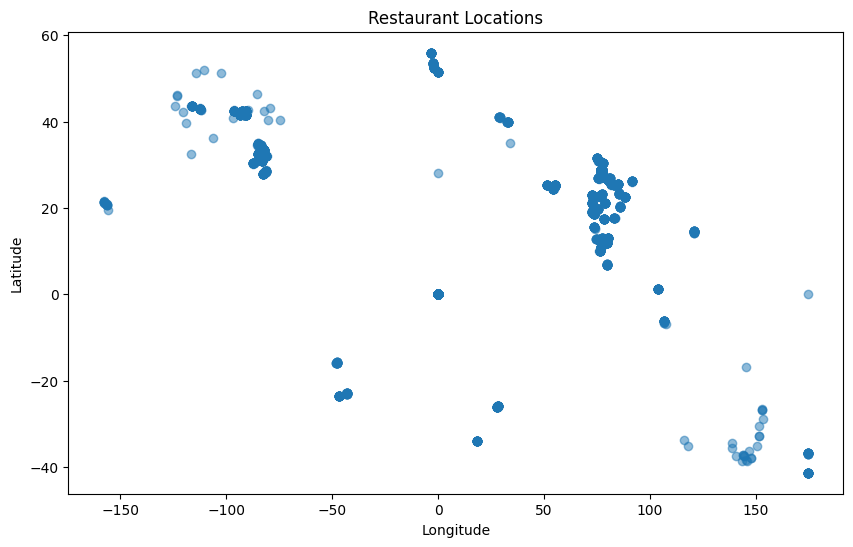

In [5]:
plt.figure(figsize=(10,6))

plt.scatter(
    df['Longitude'],
    df['Latitude'],
    alpha=0.5
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [6]:
country_counts = df["Country Code"].value_counts()

country_counts

Country Code
1      8652
216     425
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64

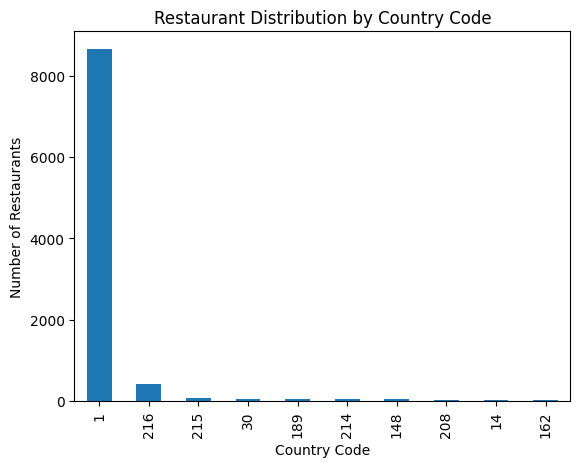

In [7]:
country_counts.head(10).plot(kind='bar')
plt.title("Restaurant Distribution by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")
plt.show()

In [8]:
city_counts = df["City"].value_counts()
city_counts.head(10)

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Ahmedabad         21
Lucknow           21
Guwahati          21
Amritsar          21
Name: count, dtype: int64

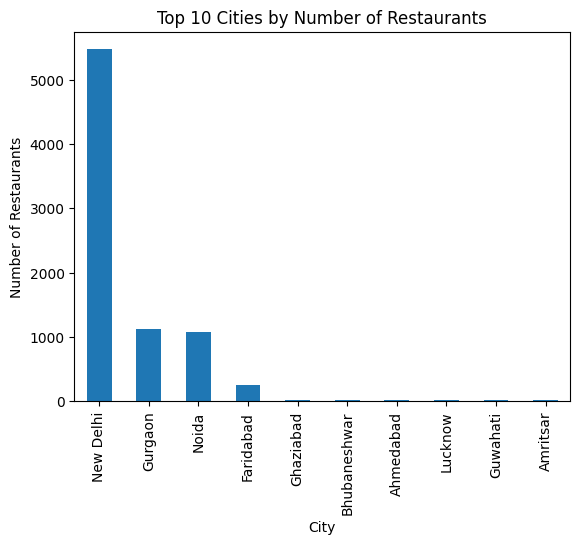

In [9]:
city_counts.head(10).plot(kind='bar')
plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.show()

In [10]:
city_rating = df.groupby("City")["Aggregate rating"].mean()
city_rating.sort_values(ascending=False).head(10)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Lincoln             4.500000
Tagaytay City       4.500000
Name: Aggregate rating, dtype: float64

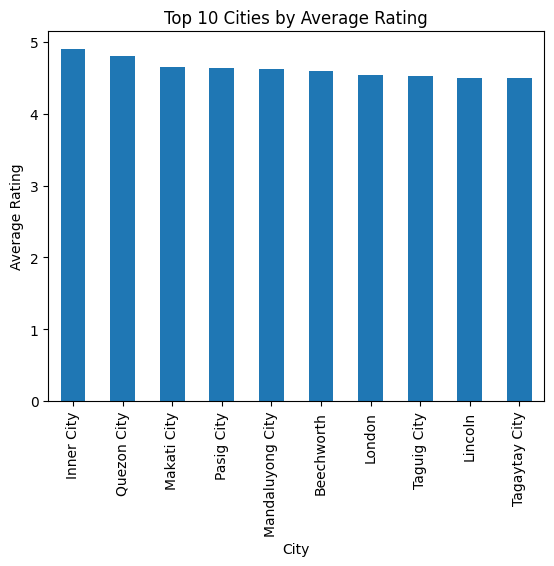

In [11]:
city_rating.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")

plt.show()

In [12]:
correlation = df["Latitude"].corr(df["Aggregate rating"])

print("Correlation between Latitude and Aggregate Rating:", correlation)

Correlation between Latitude and Aggregate Rating: 0.00019656901824328268


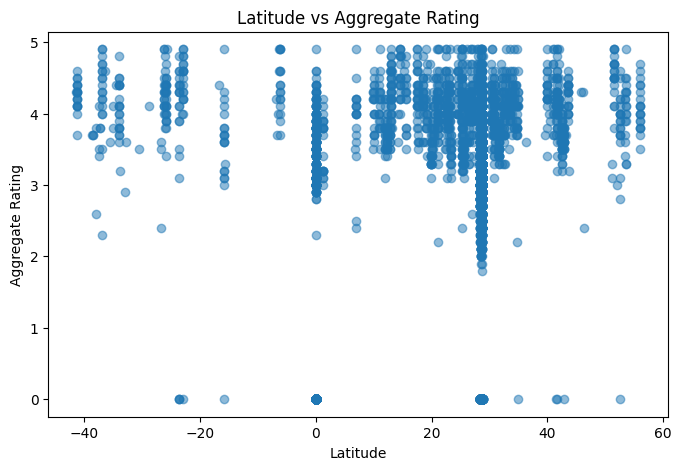

In [13]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Latitude"],
    df["Aggregate rating"],
    alpha=0.5
)

plt.title("Latitude vs Aggregate Rating")
plt.xlabel("Latitude")
plt.ylabel("Aggregate Rating")

plt.show()